<u><b><h1 style="text-align:center; line-height:25px; color:#000000; background:#EFEFEF; border: 1px solid #FF6B6B ; padding:20px;">Extracting Prevalent Topics from Citizens Complaints using NLP</h1></b></u>
<u><h2 style="text-align:center">1. Exploration step</h2></u>
**Course:** DLBDSEDA02 – Project: Data Analysis  
**Tools**:  
**Dataset:** <a href="https://www.kaggle.com/datasets/xjoury/customer-complaints-sentiment-and-priority-dataset">Customer Complaints Sentiment and Priority Dataset</a>  
**<a href="https://github.com/davidlupau/complaint-topic-modeling">GitHub repository</a>**

<b><h2 style="padding: 10px; border-left: 3px solid #FF6B6B;">Setup & Imports</h2></b>

In [17]:
import pandas as pd
import sys
from pathlib import Path

PROJECT_ROOT = next(
    p for p in [Path.cwd(), *Path.cwd().parents]
    if (p / "src").is_dir()
)
sys.path.append(str(PROJECT_ROOT / "src"))

from utils import load_dataset

print("Import successful")

Import successful


### Loading the dataset

In [18]:
df = load_dataset("Customer_Complaints_Sentiment_and_Priority_Dataset.csv")


Loading dataset...

Successfully loaded Customer_Complaints_Sentiment_and_Priority_Dataset.csv 



<b><h2 style="padding: 10px; border-left: 3px solid #FF6B6B;">Exploratory Data Analysis</h2></b>

The checks below profile the raw corpus before any cleaning. Each function lives in `src/data_exploration.py`, prints a summary and returns its result for reuse; the two plotting checks also save a PNG to `analysis_output/`.

### Shape & missing values

Before analysing the text we confirm the dataset dimensions, column types and — most importantly — that the free-text `Consumer_complaint` column has no missing values. Any missing narratives would need to be dropped, since a topic model cannot process empty documents.

In [19]:
from data_exploration import check_shape_and_missing

shape_missing = check_shape_and_missing(df)


=== Shape & missing values ===

Rows: 1750, Columns: 4

Column dtypes:
Consumer_complaint    object
Product               object
Sentiment              int64
Priority               int64

Missing values per column:
Consumer_complaint    0
Product               0
Sentiment             0
Priority              0

Missing 'Consumer_complaint' narratives: 0


No missing narratives (0 out of 1750) and no unexpected dtypes. No row-dropping needed at this stage — the full dataset is usable as-is.

---

### Duplicate narratives

Identical complaint narratives inflate the frequency of whatever terms and topics they contain, biasing an unsupervised model. Quantifying and previewing duplicates now lets us decide during cleaning whether to drop the redundant rows so each distinct complaint is weighted once.

In [20]:
from data_exploration import check_duplicates

duplicates = check_duplicates(df)


=== Duplicate narratives ===

Rows sharing a duplicated narrative: 0
Redundant rows (duplicates beyond the first): 0


Zero duplicate narratives found. No deduplication step is needed in preprocessing, every complaint is already a distinct document.

---

### Class balance across products

Checking the distribution of the `Product` column tells us whether any category dominates the corpus. Because topic models are unsupervised, a strong imbalance would mean discovered topics disproportionately reflect the largest categories, which we must keep in mind when interpreting and validating the final topics.

In [21]:
from data_exploration import check_class_balance

class_balance = check_class_balance(df)


=== Class balance (Product) ===

Number of categories: 7

                                                    count  percentage
Product                                                              
Checking or savings account or service                250       14.29
Credit card or prepaid card                           250       14.29
Credit reporting, repair, or other                    250       14.29
Debt collection                                       250       14.29
Loans                                                 250       14.29
Money transfer, virtual currency, or money service    250       14.29
Mortgage                                              250       14.29


All 7 Product categories are exactly balanced at 250 rows (14.29%) each. This means that, when we compare discovered topics against Product, any topic skew we see will reflect genuine thematic clustering, not an artifact of one category dominating the corpus.

---

### Complaint length distribution

Measuring how many words and characters each complaint contains reveals the spread between very short and very long narratives. These distributions guide preprocessing decisions such as filtering out near-empty documents and choosing a sensible maximum length, and later inform vectorization parameters like `max_features` and n-gram range.


=== Text length distribution ===

word_count: min=2, max=2618, mean=214.4, median=155.0
char_count: min=23, max=16004, mean=1174.9, median=838.5

Saved plot to: /Users/davidlupau/Documents/Filen/_IU/6th semester/32. Project Data Analysis/complaint-topic-modeling/analysis_output/text_length_distribution.png


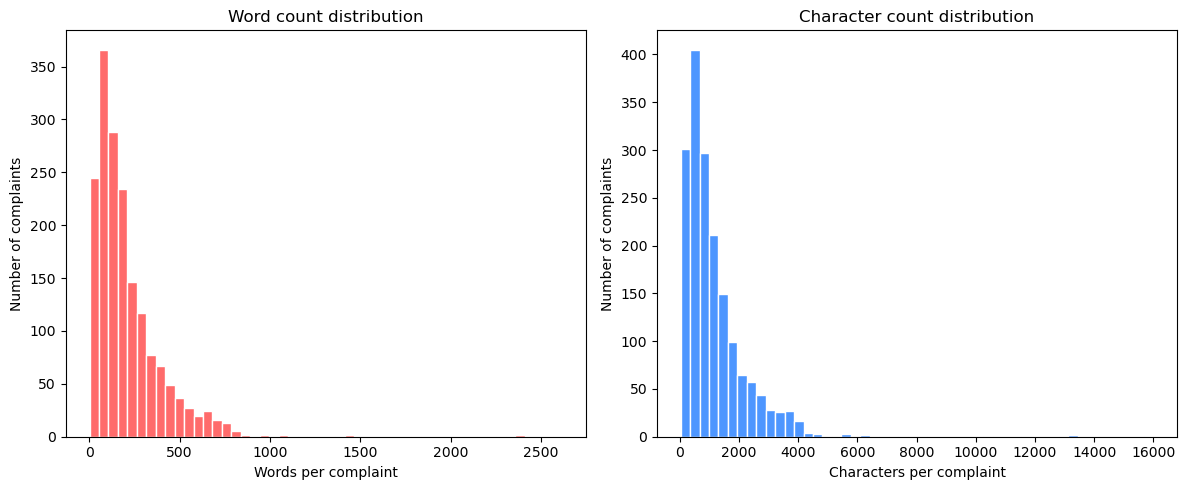

In [22]:
import matplotlib.pyplot as plt
from data_exploration import check_text_length

lengths = check_text_length(df)
plt.show()

Complaint length varies widely: from 2 words to 2,618 words, with a mean (214) noticeably above the median (155), indicating a right-skewed distribution with a handful of very long outliers. The 2-word minimum is a concern: a complaint that short carries almost no topic signal. This motivates a minimum-length filter in the next step (e.g. dropping complaints under N tokens after cleaning), and the long tail is worth keeping in mind when choosing max_features for vectorization.

---

### Most frequent raw tokens

Applying deliberately naive whitespace tokenization to the untouched text surfaces the noise we will have to deal with: common stopwords, the `XXXX` redaction placeholders, and punctuation still attached to words. Seeing what dominates the raw vocabulary directly informs our stopword list, redaction handling and cleaning steps before vectorization.


=== Top 30 raw tokens ===

token
the        14711
I          13466
XXXX       12956
to         12443
and         9781
a           7072
my          7029
of          5758
that        5676
was         5126
in          3972
on          3780
have        3613
for         3602
not         3394
they        3264
is          3117
me          2921
with        2877
this        2770
from        2130
it          2065
account     1993
be          1731
credit      1694
had         1681
as          1611
would       1377
(           1325
XXXX,       1304

Saved plot to: /Users/davidlupau/Documents/Filen/_IU/6th semester/32. Project Data Analysis/complaint-topic-modeling/analysis_output/top_raw_tokens.png


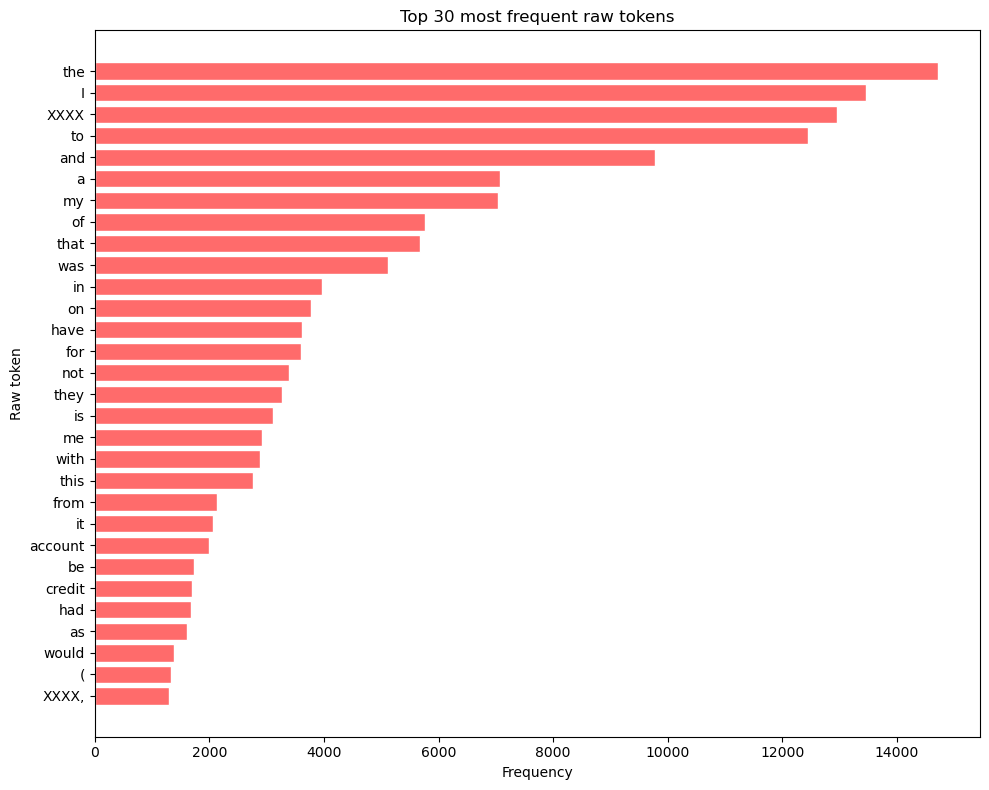

In [23]:
import matplotlib.pyplot as plt
from data_exploration import check_frequent_tokens

top_tokens = check_frequent_tokens(df, top_n=30)
plt.show()

As expected, the raw token list is dominated by English stopwords ("the", "I", "to", "and") and the XXXX redaction placeholder (12,956 occurrences, plus 1,304 more as "XXXX," — confirming punctuation is still attached to tokens at this stage). This directly confirms three preprocessing needs: stopword removal, an explicit strip of XXXX tokens (not just relying on stopword lists, since it's not a real English word), and punctuation stripping before tokenization.

---

### Manual inspection of sample complaints

Reading a handful of complete narratives end-to-end exposes structure, tone and formatting quirks that aggregate statistics cannot capture. These qualitative observations help us design concrete preprocessing rules (e.g. how to handle redactions, casing and boilerplate). A fixed `random_state` keeps the sample reproducible for the report.

In [24]:
from data_exploration import show_sample_complaints

sample = show_sample_complaints(df, n=5, random_state=42)


=== 5 sample complaints (random_state=42) ===

[1] (row 1246)
i am a XXXX on pension vet..i had XXXX every week that XXXX out sourced by the va ... my XXXX was sent to a local hospital by the outsourced nurse..the va paid the nurse but the nurse did not pay the hospital for XXXX done..the hospital billed me as the patient..i was told by the va to have all bills resubmitted for payment..the hospital said the va paid the bill already so instead of billing the people that submitted the XXXX they put it on my credit as a collection..i had the billed paid in full but its on my credit as if its my fault ... said it would remain on me to let others know ive had problems in hte past..its not my bill..please help..i am almost to the point of filing bankruptcy cause of it.the va paid once and the XXXX XXXX people did not pay the hospital..i hope u can understand my problem ..im not to good at explaining myself being im XXXX years old now..as i said please help

---------------------------------

The manual read confirms several patterns worth handling explicitly: inconsistent casing (some complaints fully lowercase), XXXX masking names, dates, and dollar amounts interchangeably, embedded currency values like {$22000.00}, and informal punctuation (repeated periods, ellipses). These observations translate into concrete cleaning rules for preprocessing step: lowercase normalization, XXXX removal, and a regex to strip currency/number artifacts.